In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

In [2]:
df = pd.read_csv('Superstore data.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12-06-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.shape

(9994, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,05-09-2016,16-12-2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [23]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')

In [24]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit',
       'shipping_days', 'year', 'month', 'profit_margin_pct',
       'profit_per_quantity'],
      dtype='object')

In [25]:
# Convert date columns from object
df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y', errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], format='%d-%m-%Y', errors='coerce')

In [26]:
# Create new derived columns
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month_name()

In [27]:
# Create profit based columns
df['profit_margin_pct'] = round((df['profit'] / df['sales']) * 100, 2)
df['profit_per_quantity'] = round(df['profit'] / df['quantity'], 2)

In [28]:
print(df.dtypes[['order_date', 'ship_date']])

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object


In [29]:
print(df[['order_date', 'ship_date', 'shipping_days', 'year', 'month', 'profit_margin_pct', 'profit_per_quantity']].head())

  order_date  ship_date  shipping_days  year     month  profit_margin_pct  \
0 2016-11-08 2016-11-11              3  2016  November              16.00   
1 2016-11-08 2016-11-11              3  2016  November              30.00   
2 2016-06-12 2016-06-16              4  2016      June              47.00   
3 2015-10-11 2015-10-18              7  2015   October             -40.00   
4 2015-10-11 2015-10-18              7  2015   October              11.25   

   profit_per_quantity  
0                20.96  
1                73.19  
2                 3.44  
3               -76.61  
4                 1.26  


# Exploratory Data Anaysis

### 1. Sales VS Profit

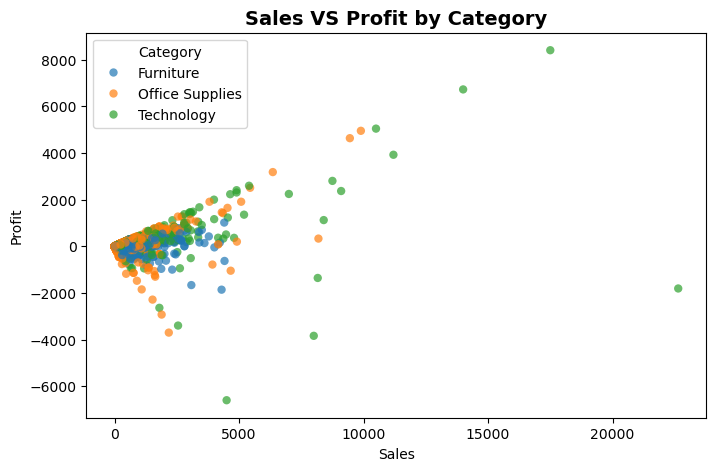

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='sales', y='profit', hue='category', alpha=0.7, edgecolor='none')
plt.title('Sales VS Profit by Category', fontsize=14, fontweight='bold')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.legend(title="Category")
plt.show()

In [31]:
# Insights:
# Positive trend overall, but some high-sales orders result in negative profit (losses),
# particularly within the Furniture category.

### 2. Profit by Region

C:\Users\dell\AppData\Local\Temp\ipykernel_8544\1663410332.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_profit, x='region', y='profit', palette='viridis')


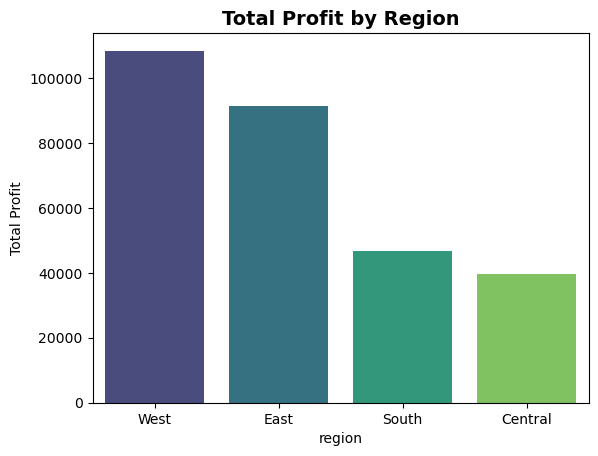

In [32]:
region_profit = df.groupby('region')['profit'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=region_profit, x='region', y='profit', palette='viridis')
plt.title('Total Profit by Region', fontsize=14, fontweight='bold')
plt.ylabel('Total Profit')
plt.show()

In [33]:
# Insights:
# West region contributes the most profit, while South performs the weakest.

### 3. Top 10 States by Sales

C:\Users\dell\AppData\Local\Temp\ipykernel_8544\2298734158.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_states, y='state', x='sales', palette='crest')


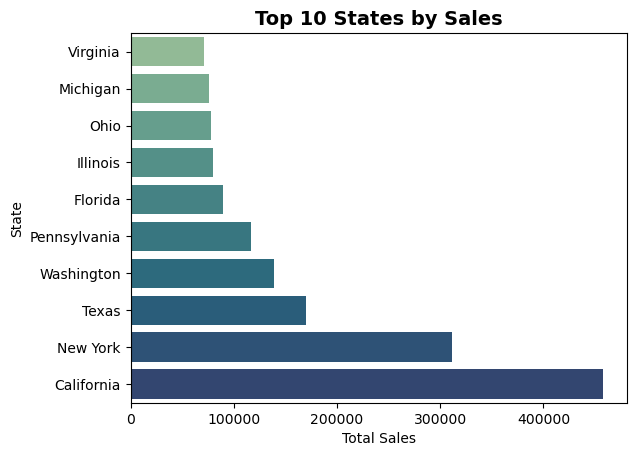

In [34]:
top_states = df.groupby('state')['sales'].sum().nlargest(10).sort_values().reset_index()
sns.barplot(data=top_states, y='state', x='sales', palette='crest')
plt.title('Top 10 States by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.show()

In [35]:
# Insights:
# California, New York, and Texas lead sales, making them key markets for performance focus.

### 4. Monthly Sales Trend

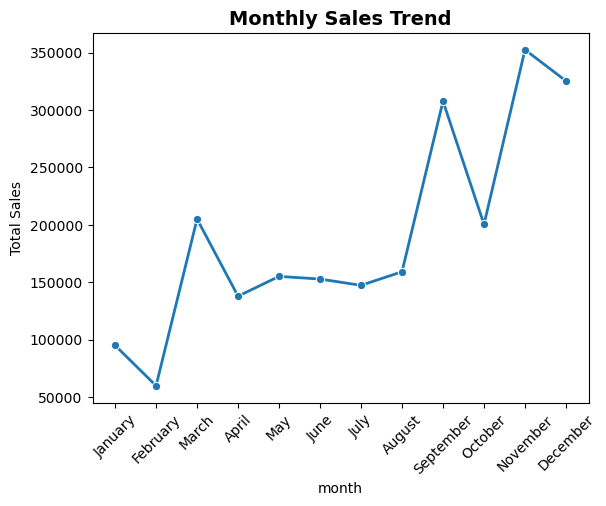

In [36]:
monthly_sales = df.groupby('month')['sales'].sum().reindex([
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]).reset_index()

sns.lineplot(data=monthly_sales, x='month', y='sales', marker='o', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("Total Sales")
plt.show()

In [37]:
# Insights:
# Sales peak in November–December, likely due to holiday shopping and end-of-year discounts.

### 5. Shipping Days Distribution

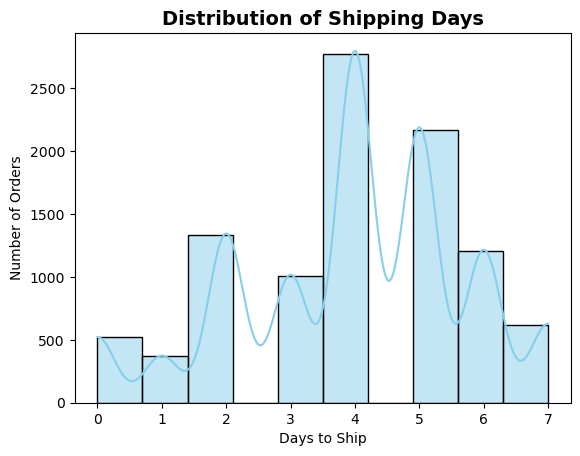

In [38]:
sns.histplot(df['shipping_days'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Shipping Days', fontsize=14, fontweight='bold')
plt.xlabel('Days to Ship')
plt.ylabel('Number of Orders')
plt.show()

In [39]:
# Insights:
# Most orders are shipped within 3–5 days, indicating an efficient delivery system overall.

### 6. Profit by Customer Segment

C:\Users\dell\AppData\Local\Temp\ipykernel_8544\2828373070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_profit, x='segment', y='profit', palette='Set2')


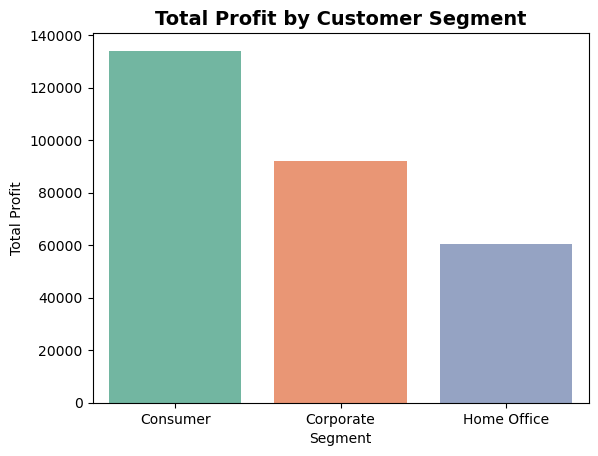

In [40]:
segment_profit = df.groupby('segment')['profit'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=segment_profit, x='segment', y='profit', palette='Set2')
plt.title('Total Profit by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Total Profit')
plt.show()

In [41]:
# Insight:
# Corporate and Consumer segments bring higher profits; Home Office lags behind.

### 7. Profit by Category

C:\Users\dell\AppData\Local\Temp\ipykernel_8544\815706032.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_profit, x='category', y='profit', palette='coolwarm')


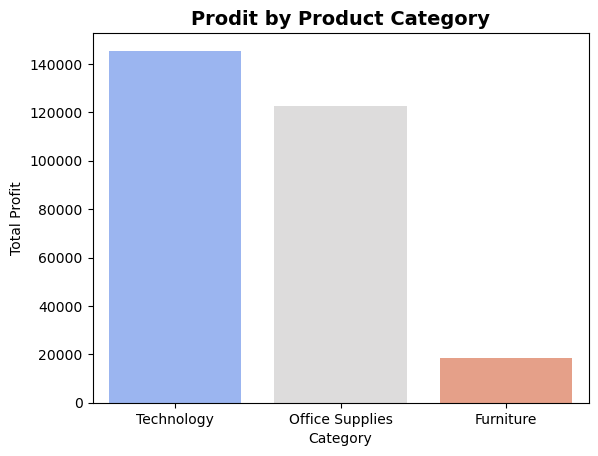

In [42]:
category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=category_profit, x='category', y='profit', palette='coolwarm')
plt.title('Prodit by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.show()

In [43]:
# Insight:
# Technology is the most profitable category; Furniture often faces losses.

### 8. Profit by Sub-Category

C:\Users\dell\AppData\Local\Temp\ipykernel_8544\3491659640.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_profit, y='sub_category', x='profit', palette='Spectral')


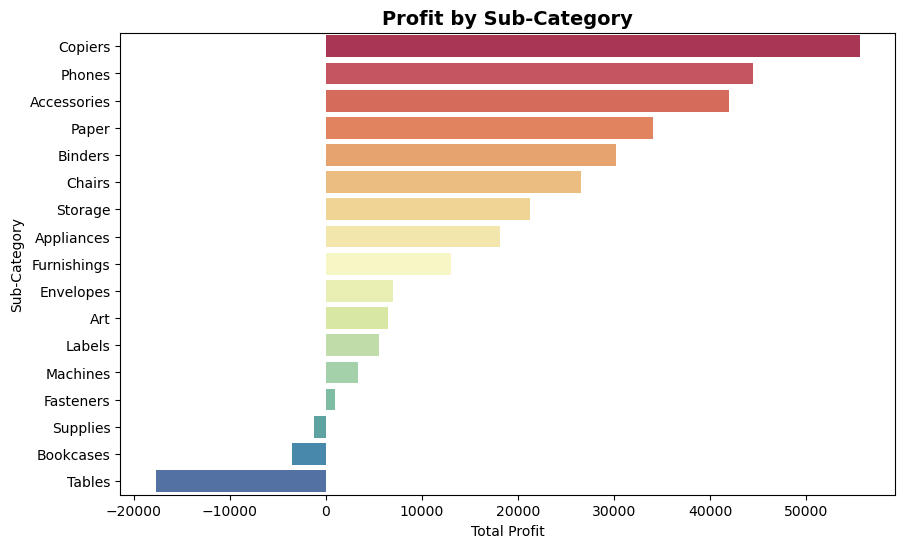

In [44]:
subcat_profit = df.groupby('sub_category')['profit'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=subcat_profit, y='sub_category', x='profit', palette='Spectral')
plt.title("Profit by Sub-Category", fontsize=14, fontweight='bold')
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.show()

In [45]:
# Insight:
# Phones, Accessories, and Copiers are highly profitable.
# Tables, Bookcases, and Supplies result in losses — need optimization.

### 9. Average Profit Margin % by Segment

C:\Users\dell\AppData\Local\Temp\ipykernel_8544\948435227.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_margin, x='segment', y='profit_margin_pct', palette='YlGnBu')


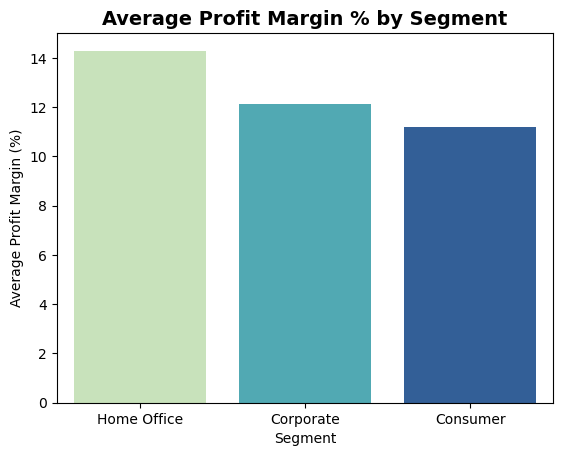

In [46]:
segment_margin = df.groupby('segment')['profit_margin_pct'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=segment_margin, x='segment', y='profit_margin_pct', palette='YlGnBu')
plt.title("Average Profit Margin % by Segment", fontsize=14, fontweight='bold')
plt.xlabel("Segment")
plt.ylabel("Average Profit Margin (%)")
plt.show()

In [47]:
# Insight:
# Corporate segment enjoys highest profit margins; Home Office has the lowest.

### 10. Average Profit Margin % by Category

C:\Users\dell\AppData\Local\Temp\ipykernel_8544\302081418.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_margin, x='category', y='profit_margin_pct', palette='YlOrRd')


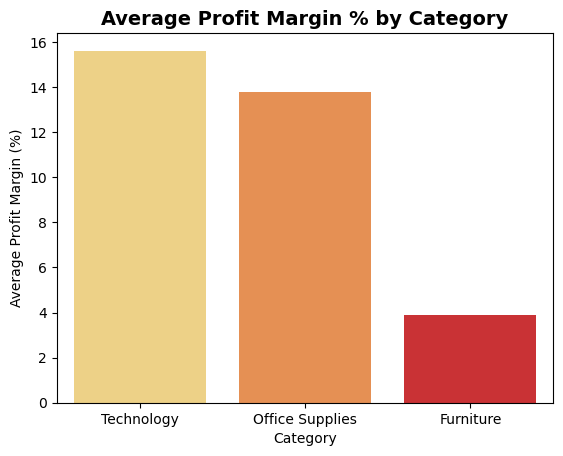

In [48]:
category_margin = df.groupby('category')['profit_margin_pct'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=category_margin, x='category', y='profit_margin_pct', palette='YlOrRd')
plt.title("Average Profit Margin % by Category", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Average Profit Margin (%)")
plt.show()

In [49]:
# Insight:
# Technology has the strongest margins, while Furniture reduces overall profitability.

## Summary Insights

In [50]:
print("Average Sales:", round(df['sales'].mean(), 2))
print("Average Profit:", round(df['profit'].mean(), 2))
print("Average Profit Margin %:", round(df['profit_margin_pct'].mean(), 2))
print("Average Shipping Days:", round(df['shipping_days'].mean(), 1))

Average Sales: 229.86
Average Profit: 28.66
Average Profit Margin %: 12.03
Average Shipping Days: 4.0


## Creating Database Connection

In [51]:
conn = mysql.connector.connect(
    host = "localhost",
    user = "root",
    password = "",
    database = "retail_sales_db"
)

print("Connection successful!")

cursor = conn.cursor()

Connection successful!


In [52]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit',
       'shipping_days', 'year', 'month', 'profit_margin_pct',
       'profit_per_quantity'],
      dtype='object')

In [53]:
from sqlalchemy import create_engine

engine = create_engine('mysql+pymysql://root:@localhost/retail_sales_db')

# Load data into MYSQL
df.to_sql('superstore_orders', con=engine, if_exists='replace', index=False)

print('Data successfully imported into MYSQL')

Data successfully imported into MYSQL


In [54]:
df.to_csv('superstore_sales_data.csv', index=False)